# Inizializzazione


In [1]:
import os
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA

In [2]:
import pandas as pd

# I nomi delle 11 colonne del MAGIC Gamma Telescope
col_names = ['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 
             'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist', 'class']

# Legge il file in locale che ti ho appena scaricato
df = pd.read_csv("magic04.data", names=col_names)

# Separa le features dal target per mantenere la struttura del tuo vecchio codice
X = df.drop('class', axis=1)
y = df['class'].map({'h': 0, 'g': 1}) # Mappa le lettere in 0 e 1 come avevi fatto tu

# Diamo un'occhiata
print("Dataset caricato con successo in locale! Dimensioni:", X.shape)

Dataset caricato con successo in locale! Dimensioni: (19020, 10)


In [3]:
df.shape

(19020, 11)

In [4]:
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [5]:
df.tail()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
19015,21.3846,10.9170,2.6161,0.5857,0.3934,15.2618,11.5245,2.8766,2.4229,106.8258,h
19016,28.9452,6.7020,2.2672,0.5351,0.2784,37.0816,13.1853,-2.9632,86.7975,247.4560,h
19017,75.4455,47.5305,3.4483,0.1417,0.0549,-9.3561,41.0562,-9.4662,30.2987,256.5166,h
19018,120.5135,76.9018,3.9939,0.0944,0.0683,5.8043,-93.5224,-63.8389,84.6874,408.3166,h
19019,187.1814,53.0014,3.2093,0.2876,0.1539,-167.3125,-168.4558,31.4755,52.7310,272.3174,h


In [6]:
df.dtypes

fLength     float64
fWidth      float64
fSize       float64
fConc       float64
fConc1      float64
fAsym       float64
fM3Long     float64
fM3Trans    float64
fAlpha      float64
fDist       float64
class           str
dtype: object

In [7]:
# Imposto il target come categorico
df["class"] = df["class"].astype("category")

In [8]:
df.dtypes

fLength      float64
fWidth       float64
fSize        float64
fConc        float64
fConc1       float64
fAsym        float64
fM3Long      float64
fM3Trans     float64
fAlpha       float64
fDist        float64
class       category
dtype: object

In [9]:
df['class'] = df['class'].map({'h': 0, 'g': 1})

# Verifica dei target
print(df['class'].value_counts())

class
1    12332
0     6688
Name: count, dtype: int64


In [130]:
# Prepariamo X e y dai dati ORIGINALI (non ancora scalati)
X = df.drop(['class'], axis=1)
y = df['class']
seed = 42

# 1. Primo split: separiamo il Training Set (60%) da un set temporaneo (40%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=seed,
    stratify=y
)

# 2. Secondo split: dividiamo il set temporaneo esattamente a metà (50% a testa)
# In questo modo il 30% iniziale diventa: 20% Validation e 20% Test rispetto al totale
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=seed,
    stratify=y_temp
)

In [19]:
df_train= pd.concat([X_train, y_train], axis=1)

# Analisi Esplorativa

## Controllo NAN e Duplicati

In [20]:
# Verifica dei valori NaN
print("Valori mancanti per colonna:")
print(df.isnull().sum())

# Verifica dei duplicati
print(f"\nDuplicati trovati: {df.duplicated().sum()}")
# Elimina duplicati
df_train = df_train.drop_duplicates()

Valori mancanti per colonna:
fLength     0
fWidth      0
fSize       0
fConc       0
fConc1      0
fAsym       0
fM3Long     0
fM3Trans    0
fAlpha      0
fDist       0
class       0
dtype: int64

Duplicati trovati: 0


In [21]:
df_train.shape

(11343, 11)

## Statistiche Descrittive e Plot

In [23]:
df_train.describe()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist
count,11343.000000,11343.000000,11343.000000,11343.000000,11343.000000,11343.000000,11343.000000,11343.000000,11343.000000,11343.000000
mean,53.351386,22.218855,2.823313,0.380843,0.214660,-3.710331,10.404127,0.192987,27.596328,193.939713
std,42.725321,18.630817,0.472776,0.183095,0.110453,59.387455,51.620538,21.271545,26.009134,74.829092
min,7.360600,0.000000,1.941300,0.013700,0.000800,-457.916100,-318.300200,-205.894700,0.000000,1.282600
25%,24.345500,11.921500,2.477100,0.236700,0.129000,-20.034650,-12.892300,-10.849650,5.574000,142.405000
50%,37.043000,17.104100,2.736800,0.354700,0.196400,4.428500,15.244500,0.000000,17.658000,192.198000
75%,70.240900,24.683100,3.099600,0.502950,0.284750,24.378000,36.027550,10.850100,45.674400,240.711600
max,334.177000,228.038500,5.179500,0.893000,0.643000,575.240700,238.321000,179.851000,90.000000,495.561000


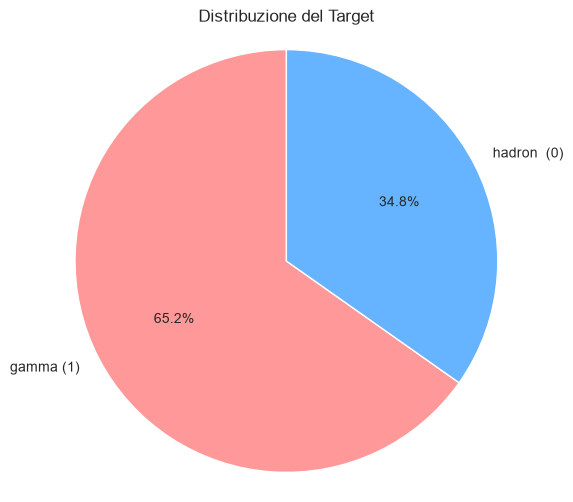

In [22]:
# Diagramma a torta
signal_class = df_train['class'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(signal_class, labels=['gamma (1)', 'hadron  (0)'], autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title('Distribuzione del Target')
plt.axis('equal')
plt.show()

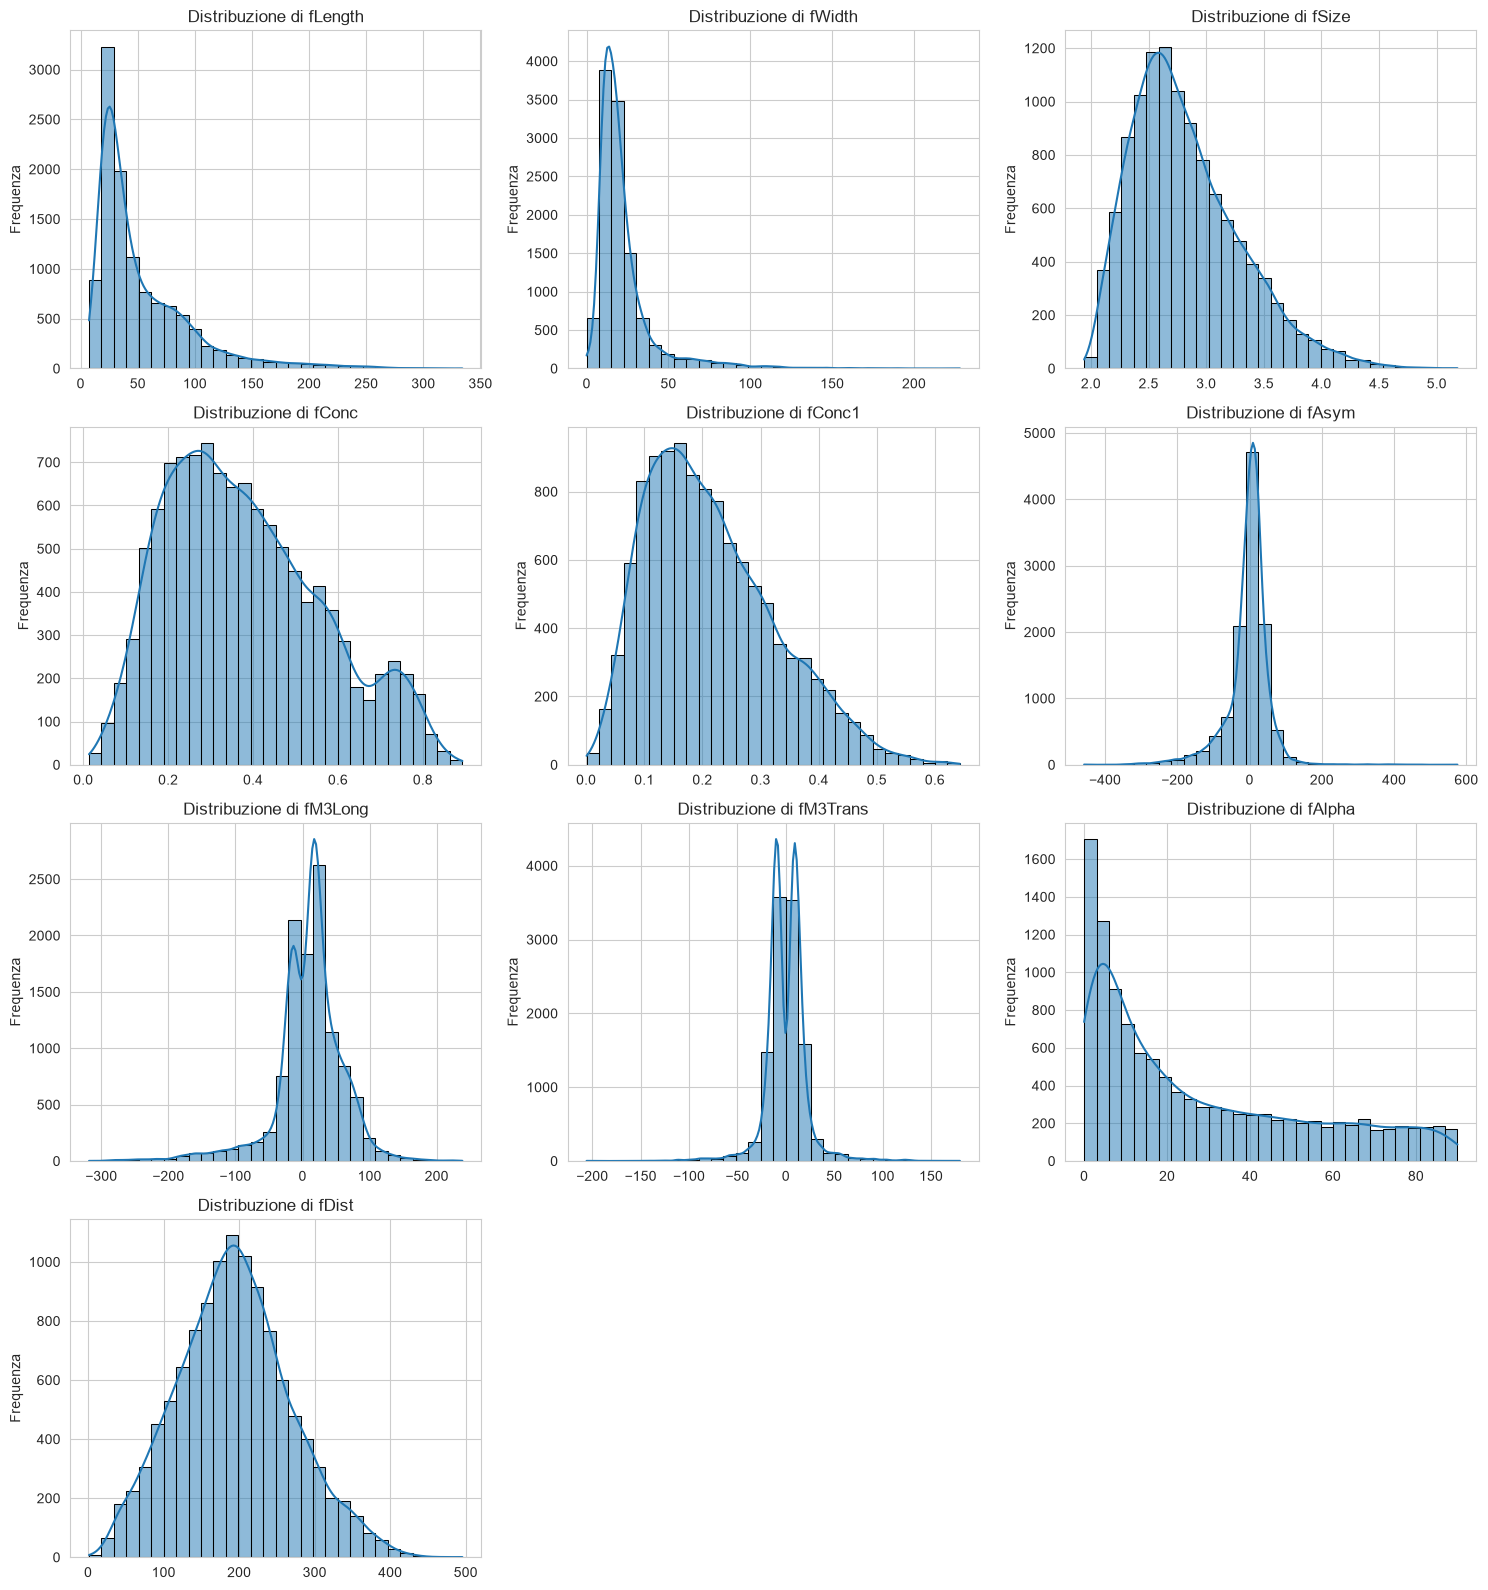

In [24]:
# Istogrammi per le distribuzioni
# Seleziona solo le colonne numeriche ed esclude la target 'class'
numeric_cols = df_train.select_dtypes(include=['float64', 'int64']).columns
numeric_cols = [c for c in numeric_cols if c != 'class']
sns.set_style("whitegrid")
n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)
plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df[col], kde=True, bins=30, edgecolor='black')
    plt.title(f'Distribuzione di {col}')
    plt.xlabel('')
    plt.ylabel('Frequenza')

plt.tight_layout()
plt.show()

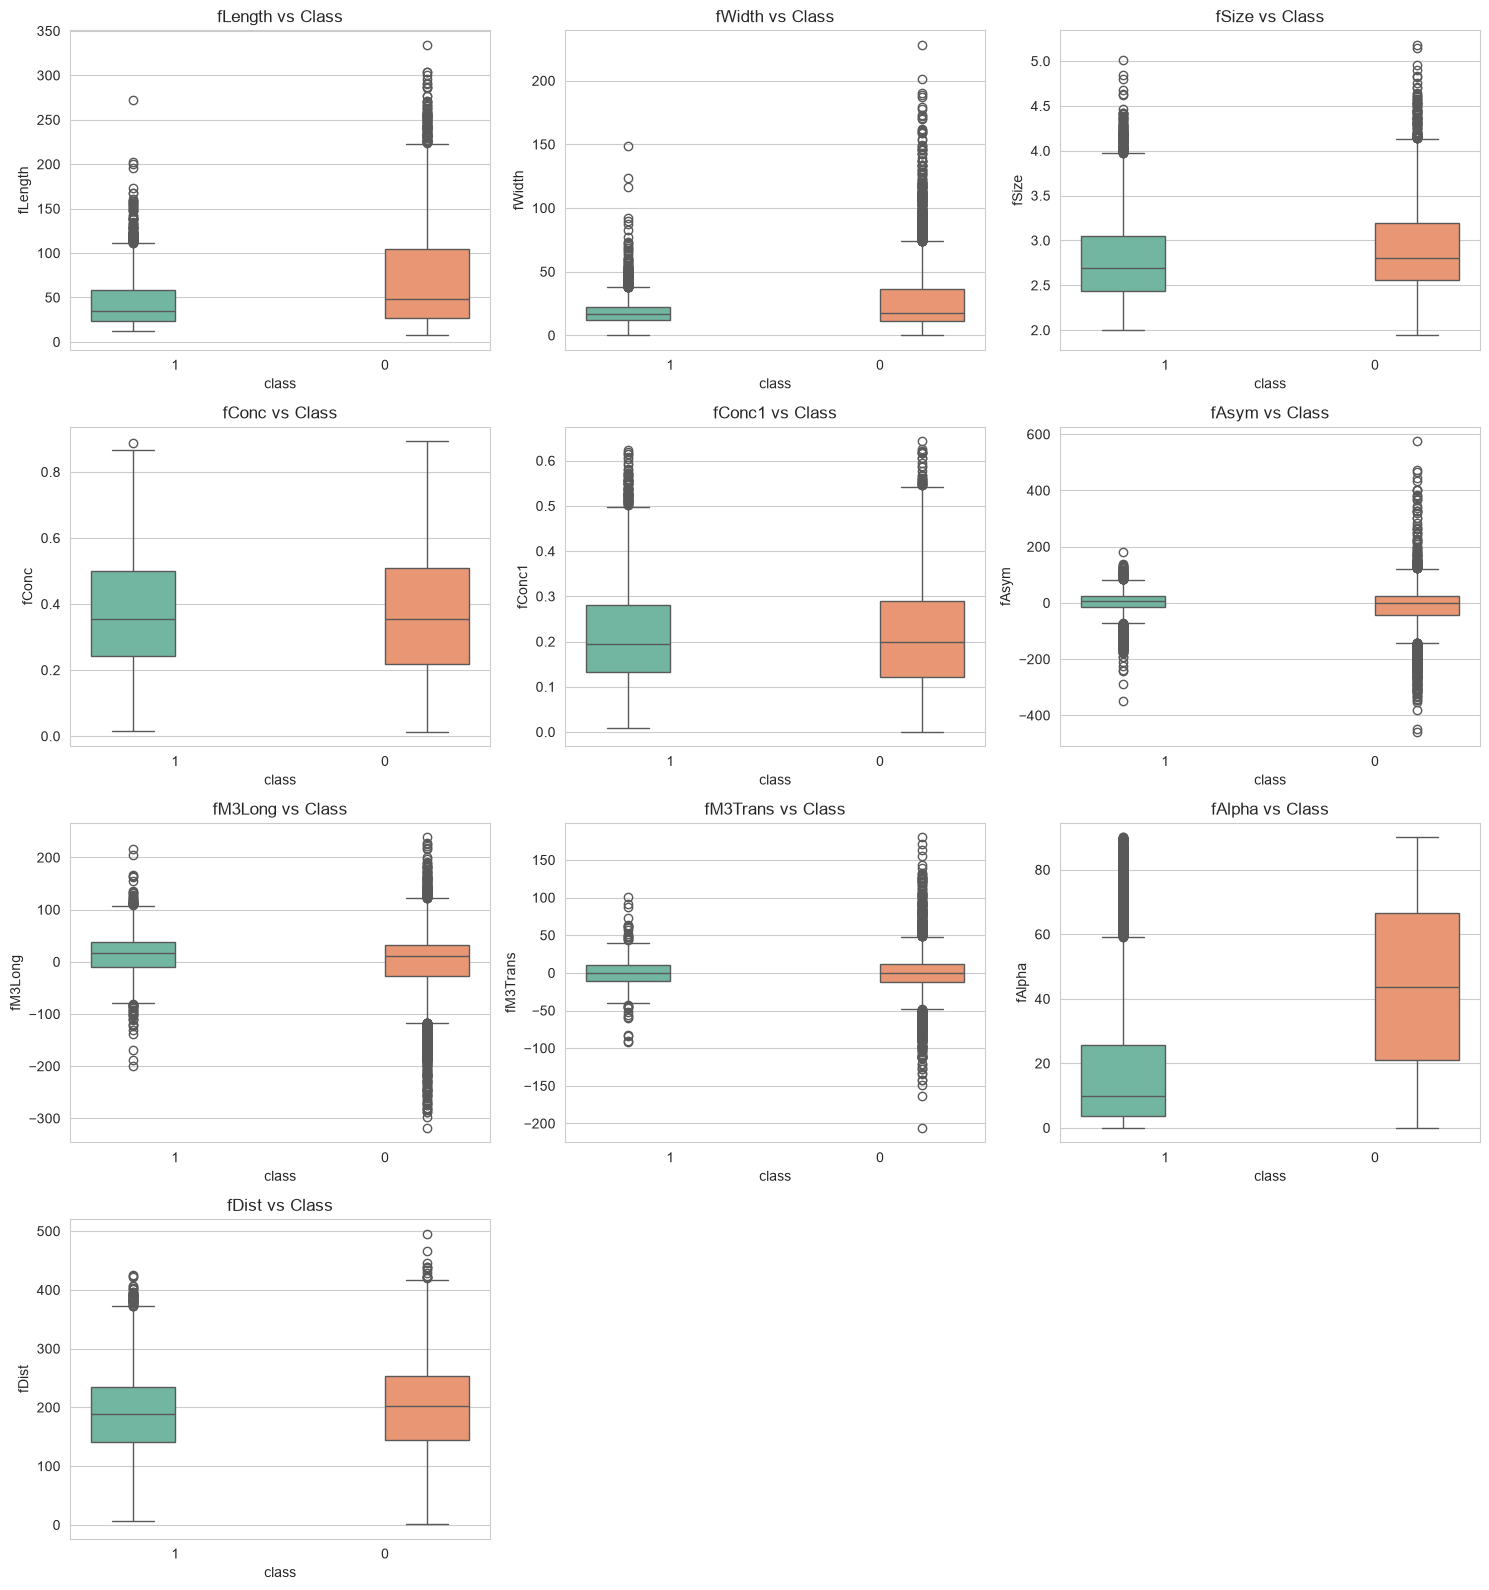

In [25]:
plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    # hue='Class' colora diversamente le due specie (0 e 1)
    sns.boxplot(x='class', y=col, hue='class', data=df, palette='Set2',
                legend=False)
    plt.title(f'{col} vs Class')

plt.tight_layout()
plt.show()

##Correlazioni

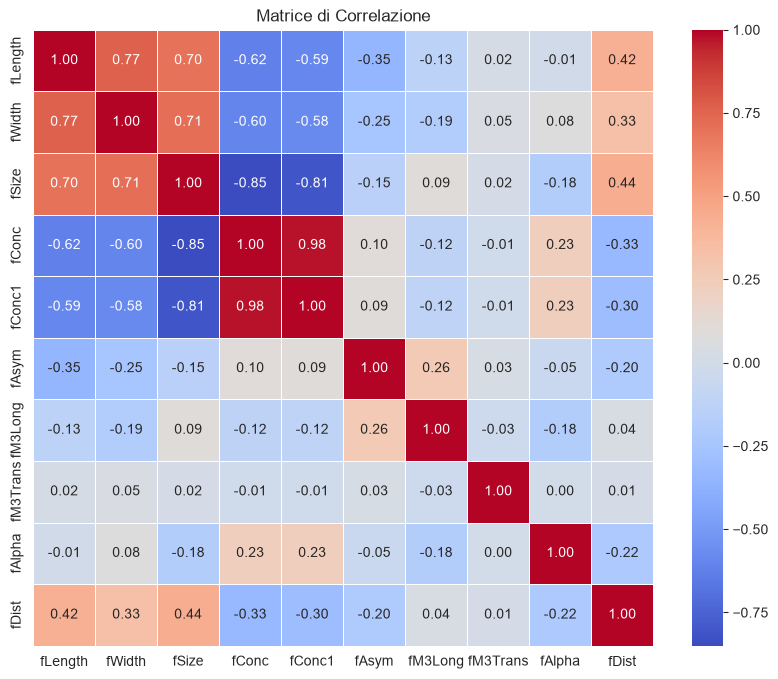

In [26]:
plt.figure(figsize=(10, 8))

# Calcola correlazione di convarianza
corr_matrix = df_train[numeric_cols].corr()

# Disegna la heatmap
sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            linewidths=0.5)

plt.title('Matrice di Correlazione')
plt.show()

In [131]:
scaler = StandardScaler()

# Addestriamo lo scaler SOLO sul Train e trasformiamo
X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

# Trasformiamo il Test usando le statistiche del Train
X_test_scaled = scaler.transform(X_test)

In [156]:
y_train = y_train.astype("int64")
y_test = y_test.astype("int64")
y_val = y_val.astype("int64")

In [166]:
def add_gaussian_noise(X, noise_level=0.1, seed=42):
    np.random.seed(seed)
    
    noise = np.random.normal(loc=0.0, scale=noise_level, size=X.shape)
    
    # Applichiamo il rumore ai dati
    X_noisy = X + noise
    
    return X_noisy

In [167]:
# Creiamo 3 versioni del training set con intensità di rumore crescente
X_train_noisy_05 = add_gaussian_noise(X_train_scaled, noise_level=0.10) # Rumore basso (5%)
X_train_noisy_15 = add_gaussian_noise(X_train_scaled, noise_level=0.30) # Rumore medio (15%)
X_train_noisy_30 = add_gaussian_noise(X_train_scaled, noise_level=0.50) # Rumore alto (30%)

In [174]:
import numpy as np

def add_label_noise(y, noise_level=0.1, seed=42):
    """
    Inverte casualmente le etichette binarie (0 in 1 e viceversa)
    per una determinata percentuale di dati.
    
    Parametri:
    - y: Array o Pandas Series con le etichette vere (0 e 1).
    - noise_level: Percentuale di rumore (0.1 = 10%, 0.3 = 30%, 0.5 = 50%).
    
    Ritorna:
    - Un array numpy con le etichette sporcate.
    """
    np.random.seed(seed)
    
    # Creiamo una copia per non modificare le y originali inavvertitamente
    y_noisy = np.array(y).copy()
    
    # Calcoliamo quante righe rovinare
    n_samples = len(y_noisy)
    n_flips = int(n_samples * noise_level)
    
    # Scegliamo 'n_flips' indici casuali da invertire, senza rimpiazzo
    flip_indices = np.random.choice(n_samples, size=n_flips, replace=False)
    
    # L'operazione "1 - valore" inverte i binari: (1-0)=1, (1-1)=0
    y_noisy[flip_indices] = 1 - y_noisy[flip_indices]
    
    return y_noisy

In [175]:
X_train_fn_10 = add_gaussian_noise(X_train_scaled, noise_level=0.10)
X_train_fn_30 = add_gaussian_noise(X_train_scaled, noise_level=0.30)
X_train_fn_50 = add_gaussian_noise(X_train_scaled, noise_level=0.50)


In [176]:
y_train_ln_10 = add_label_noise(y_train, noise_level=0.10)
y_train_ln_30 = add_label_noise(y_train, noise_level=0.30)
y_train_ln_50 = add_label_noise(y_train, noise_level=0.50)

# Modelli

In [198]:
# Tutti import che servirà per modelli
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.utils import class_weight
import tensorflow as tf
from sklearn.metrics import roc_curve, roc_auc_score
from scipy.interpolate import interp1d
import numpy as np

## Rete neurale

In [213]:
def train_base_network(X_train_input, y_train_input, X_val_input, y_val_input, epochs=75, batch_size=32, verbose=0):
    """
    Inizializza e addestra la Rete Neurale Base.
    Ritorna il modello addestrato e l'oggetto 'history' contenente le metriche per i grafici.
    """
    print(f"-> Creazione e addestramento della rete in corso... (Epochs: {epochs})")
    
    # 1. Definizione Rete (ricreata da zero ad ogni chiamata)
    model = Sequential()
    model.add(Dense(32, input_shape=(10,), activation='relu'))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    # 2. Compilazione
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    model.compile(loss='binary_crossentropy', 
                  optimizer=optimizer,
                  metrics=['accuracy'])
    # 3. Addestramento
    history = model.fit(
        X_train_input, y_train_input,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val_input, y_val_input),
        verbose=1 # verbose=0 nasconde la barra di progresso, metti 1 se vuoi vederla
    )
    
    # Stampiamo il risultato finale raggiunto sull'ultima epoca
    val_acc = history.history['val_accuracy'][-1]
    print(f"-> Addestramento completato! Validation Accuracy finale: {val_acc:.4f}\n")
    
    return model, history

In [201]:
def evaluate_network(model, history, X_test_input, y_test_input, model_name="Modello"):
    """
    Mostra i grafici di addestramento (Loss/Accuracy), la matrice di confusione
    e stampa il classification report per il modello passato come parametro.
    """
    print(f"\n" + "="*50)
    print(f" RISULTATI ESPERIMENTO: {model_name}")
    print("="*50)
    
    # 1. Grafici di Accuracy e Loss (Affiancati su due colonne)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Accuracy Plot
    axes[0].plot(history.history['accuracy'], label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Validation')
    axes[0].set_title(f'{model_name} - Accuracy')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend(loc='lower right')
    axes[0].grid(True)
    
    # Loss Plot
    axes[1].plot(history.history['loss'], label='Train')
    axes[1].plot(history.history['val_loss'], label='Validation')
    axes[1].set_title(f'{model_name} - Loss')
    axes[1].set_ylabel('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend(loc='upper right')
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()

    # 2. Valutazione Loss e Accuracy numerica
    score = model.evaluate(X_test_input, y_test_input, verbose=0)
    print(f'Test loss: {score[0]:.4f}')
    print(f'Test accuracy: {score[1]:.4f}')

    # 3. Predizione e conversione in 0 o 1
    y_pred_probs = model.predict(X_test_input, verbose=0)
    y_pred_nn = (y_pred_probs > 0.5).astype("int64")

    # 4. Matrice di Confusione
    cm = confusion_matrix(y_test_input, y_pred_nn)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    # 5. Report finale
    print(f"Accuratezza Finale: {accuracy_score(y_test_input, y_pred_nn):.4f}")
    print("\nReport di Classificazione:")
    print(classification_report(y_test_input, y_pred_nn))
    print("="*50 + "\n")

In [202]:
def evaluate_network(model, history, X_test_input, y_test_input, model_name="Modello"):
    """
    Mostra i grafici di addestramento (Loss/Accuracy), la matrice di confusione
    e stampa il classification report per il modello passato come parametro.
    """
    print(f"\n" + "="*50)
    print(f" RISULTATI ESPERIMENTO: {model_name}")
    print("="*50)
    
    # 1. Grafici di Accuracy e Loss (Affiancati su due colonne)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Accuracy Plot
    axes[0].plot(history.history['accuracy'], label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Validation')
    axes[0].set_title(f'{model_name} - Accuracy')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend(loc='lower right')
    axes[0].grid(True)
    
    # Loss Plot
    axes[1].plot(history.history['loss'], label='Train')
    axes[1].plot(history.history['val_loss'], label='Validation')
    axes[1].set_title(f'{model_name} - Loss')
    axes[1].set_ylabel('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend(loc='upper right')
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()

    # 2. Valutazione Loss e Accuracy numerica
    score = model.evaluate(X_test_input, y_test_input, verbose=0)
    print(f'Test loss: {score[0]:.4f}')
    print(f'Test accuracy: {score[1]:.4f}')

    # 3. Predizione e conversione in 0 o 1
    y_pred_probs = model.predict(X_test_input, verbose=0)
    y_pred_nn = (y_pred_probs > 0.5).astype("int64")

    # 4. Matrice di Confusione
    cm = confusion_matrix(y_test_input, y_pred_nn)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    # 5. Report finale
    print(f"Accuratezza Finale: {accuracy_score(y_test_input, y_pred_nn):.4f}")
    print("\nReport di Classificazione:")
    print(classification_report(y_test_input, y_pred_nn))
    print("="*50 + "\n")

## Random forest

In [203]:
def train_random_forest(X_train_input, y_train_input, n_estimators=100, seed=42):
    """
    Addestra un Random Forest Base.
    Ritorna il modello addestrato.
    """
    print(f"-> Addestramento Random Forest in corso... (n_estimators: {n_estimators})")
    
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        random_state=seed
    )
    model.fit(X_train_input, y_train_input)
    
    print(f"-> Addestramento completato!\n")
    return model

In [212]:
def evaluate_random_forest(model, X_test_input, y_test_input, model_name="Random Forest"):
    """
    Mostra la matrice di confusione e stampa il classification report
    per un modello sklearn. Stessa struttura di evaluate_network.
    """
    print(f"\n" + "="*50)
    print(f" RISULTATI ESPERIMENTO: {model_name}")
    print("="*50)

    # 1. Predizione
    y_pred = model.predict(X_test_input)

    # 2. Accuracy numerica
    print(f'Test accuracy: {accuracy_score(y_test_input, y_pred):.4f}')

    # 3. Matrice di Confusione
    cm = confusion_matrix(y_test_input, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    # 4. Report finale
    print(f"Accuratezza Finale: {accuracy_score(y_test_input, y_pred):.4f}")
    print("\nReport di Classificazione:")
    print(classification_report(y_test_input, y_pred))
    print("="*50 + "\n")

In [204]:
# Addestramento della rete neurale
# EarlyStopping ferma il training se il modello smette di migliorare
early_stop = EarlyStopping(monitor='val_loss', patience=20,
                           restore_best_weights=True)

# Calcola i pesi inversamente proporzionali alla frequenza per bilanciare
# si usa y_train_new, non tutto y
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_new),
    y=y_train_new
)

class_weights_dict = dict(enumerate(weights))

print(f"Pesi calcolati: {class_weights_dict}")


Pesi calcolati: {0: np.float64(1.4379292128895933), 1: np.float64(0.7665446353139961)}


In [ ]:
# 1. Esperimento: Dati Puliti (Baseline)
model_clean, history_clean = train_base_network(X_train_scaled, y_train, X_val_scaled, y_val)

-> Creazione e addestramento della rete in corso... (Epochs: 75)
Epoch 1/75


/Users/matiasbonoli/Downloads/architettura/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 664us/step - accuracy: 0.7324 - loss: 0.5542 - val_accuracy: 0.8030 - val_loss: 0.4295
Epoch 2/75
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 386us/step - accuracy: 0.8141 - loss: 0.3994 - val_accuracy: 0.8325 - val_loss: 0.3831
Epoch 3/75
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 372us/step - accuracy: 0.8382 - loss: 0.3717 - val_accuracy: 0.8422 - val_loss: 0.3649
Epoch 4/75
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 362us/step - accuracy: 0.8479 - loss: 0.3568 - val_accuracy: 0.8462 - val_loss: 0.3517
Epoch 5/75
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 382us/step - accuracy: 0.8564 - loss: 0.3472 - val_accuracy: 0.8484 - val_loss: 0.3470
Epoch 6/75
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 367us/step - accuracy: 0.8589 - loss: 0.3406 - val_accuracy: 0.8528 - val_loss: 0.3385
Epoch 7/75
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 352us/step - accuracy: 0.8608 - loss: 0.3344 - val_accuracy: 0.8607 - val_loss: 0.3349
Epoch 8/75
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 372us/step - accuracy: 0.8627 - loss: 0.3303 - val_accurac

In [206]:


# 2. Esperimento: Dati con 10% di rumore
model_noise_10_fn, history_noise_10_fn = train_base_network(X_train_fn_10, y_train, X_val_scaled, y_val)

# 3. Esperimento: Dati con 30% di rumore
model_noise_30_fn, history_noise_30_fn = train_base_network(X_train_fn_30, y_train, X_val_scaled, y_val)

# 4. Esperimento: Dati con 50% di rumore
model_noise_50_fn, history_noise_50_fn = train_base_network(X_train_fn_50, y_train, X_val_scaled, y_val)

-> Creazione e addestramento della rete in corso... (Epochs: 75)
Epoch 1/75
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 671us/step - accuracy: 0.7691 - loss: 0.5070 - val_accuracy: 0.8008 - val_loss: 0.4245
Epoch 2/75
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 373us/step - accuracy: 0.8126 - loss: 0.4072 - val_accuracy: 0.8193 - val_loss: 0.3939
Epoch 3/75
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 384us/step - accuracy: 0.8309 - loss: 0.3842 - val_accuracy: 0.8325 - val_loss: 0.3777
Epoch 4/75
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 374us/step - accuracy: 0.8391 - loss: 0.3700 - val_accuracy: 0.8383 - val_loss: 0.3686
Epoch 5/75
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 385us/step - accuracy: 0.8442 - loss: 0.3593 - val_accuracy: 0.8471 - val_loss: 0.3551
Epoch 6/75
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 364us/step - accuracy: 0.8506 - loss: 0.3510 - val_accuracy: 0.8510 - val_loss: 0.3486
Epoch 7/75
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 366us/step - accuracy: 0.8536 - loss: 0.3459 - val_accuracy: 0.8541 - val_loss: 0.3451
Epoch 8/75
213/213 ━━━━━━


 RISULTATI ESPERIMENTO: Baseline (Dati Puliti)


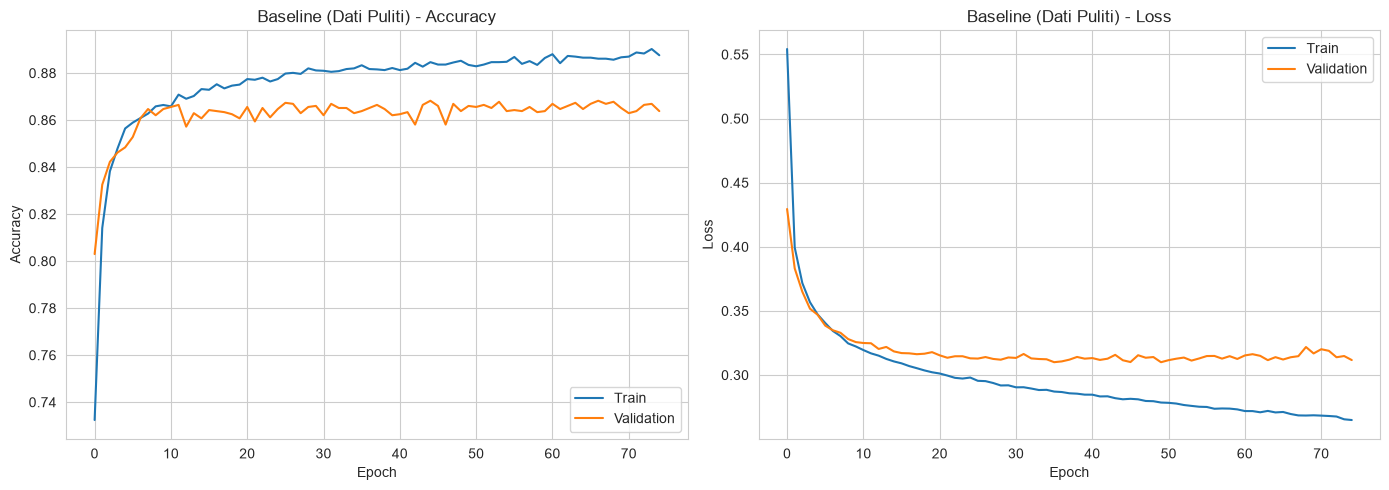

Test loss: 0.3114
Test accuracy: 0.8792


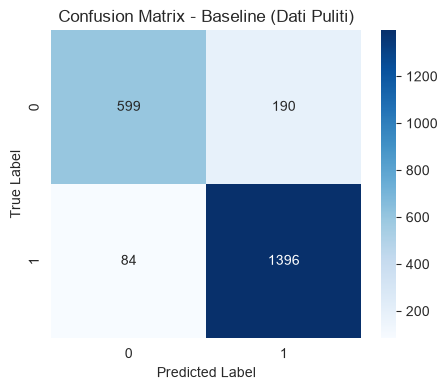

Accuratezza Finale: 0.8792

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.88      0.76      0.81       789
           1       0.88      0.94      0.91      1480

    accuracy                           0.88      2269
   macro avg       0.88      0.85      0.86      2269
weighted avg       0.88      0.88      0.88      2269



 RISULTATI ESPERIMENTO: Rumore 10%


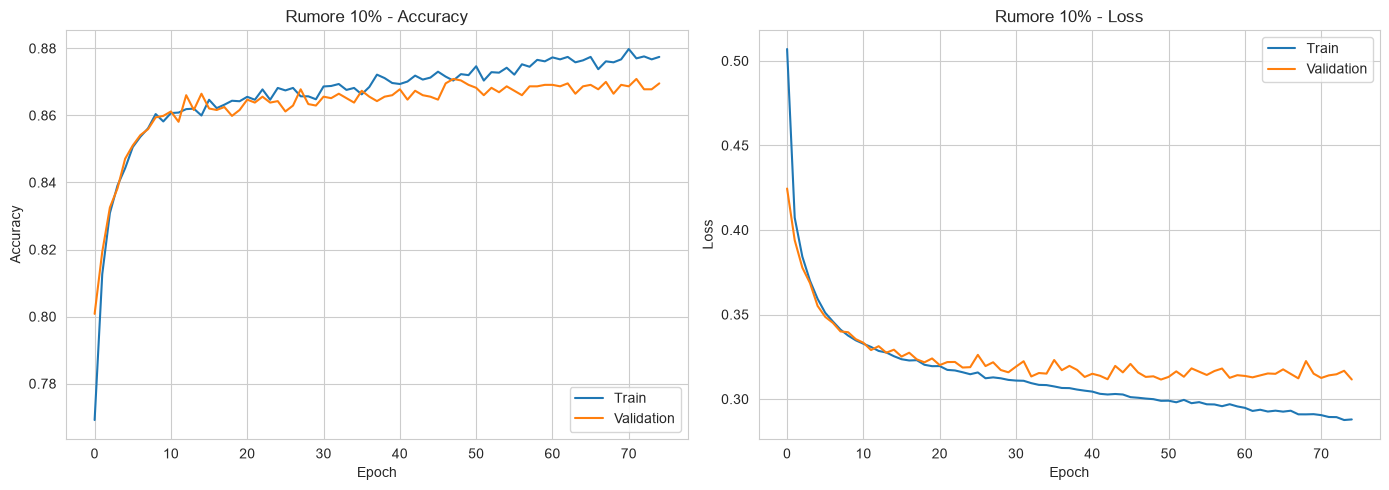

Test loss: 0.3133
Test accuracy: 0.8735


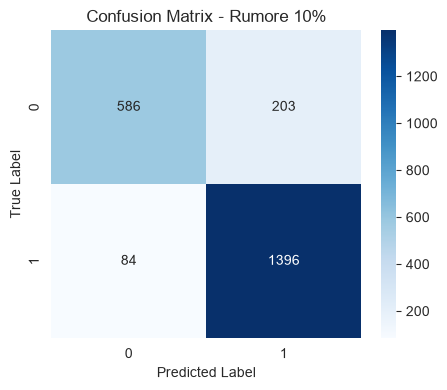

Accuratezza Finale: 0.8735

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.87      0.74      0.80       789
           1       0.87      0.94      0.91      1480

    accuracy                           0.87      2269
   macro avg       0.87      0.84      0.86      2269
weighted avg       0.87      0.87      0.87      2269



 RISULTATI ESPERIMENTO: Rumore 30%


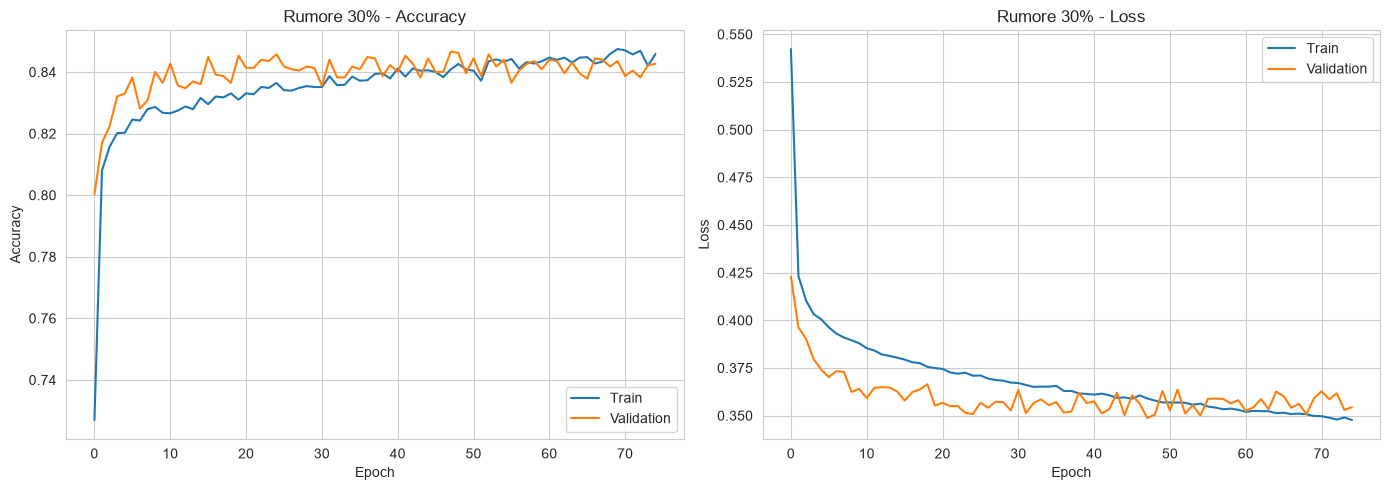

Test loss: 0.3530
Test accuracy: 0.8541


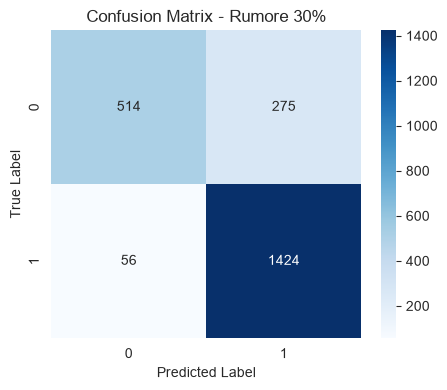

Accuratezza Finale: 0.8541

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.90      0.65      0.76       789
           1       0.84      0.96      0.90      1480

    accuracy                           0.85      2269
   macro avg       0.87      0.81      0.83      2269
weighted avg       0.86      0.85      0.85      2269



 RISULTATI ESPERIMENTO: Rumore 50%


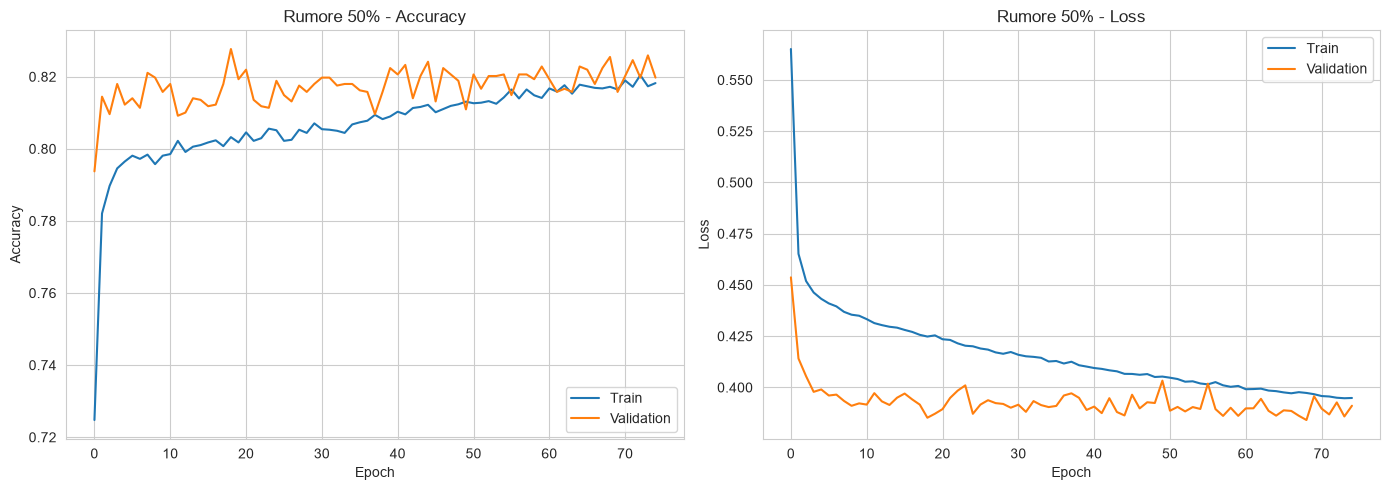

Test loss: 0.3943
Test accuracy: 0.8277


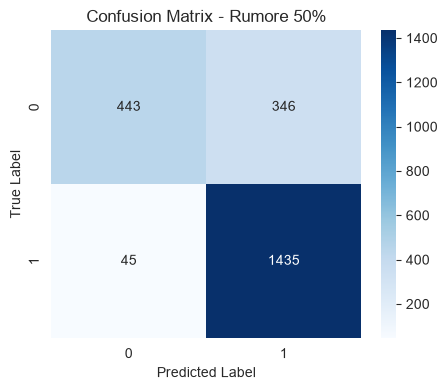

Accuratezza Finale: 0.8277

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.91      0.56      0.69       789
           1       0.81      0.97      0.88      1480

    accuracy                           0.83      2269
   macro avg       0.86      0.77      0.79      2269
weighted avg       0.84      0.83      0.82      2269




In [207]:
# 1. Valutazione Modello sui dati puliti
evaluate_network(model_clean, history_clean, X_test_scaled, y_test, model_name="Baseline (Dati Puliti)")

# 2. Valutazione Modello con rumore al 10%
evaluate_network(model_noise_10_fn, history_noise_10_fn, X_test_scaled, y_test, model_name="Rumore 10%")

# 3. Valutazione Modello con rumore al 30%
evaluate_network(model_noise_30_fn, history_noise_30_fn, X_test_scaled, y_test, model_name="Rumore 30%")

# 4. Valutazione Modello con rumore al 50%
evaluate_network(model_noise_50_fn , history_noise_50_fn, X_test_scaled, y_test, model_name="Rumore 50%")

In [208]:
# 1. Esperimento: Dati Puliti (Baseline)
model_clean, history_clean = train_base_network(X_train_scaled, y_train, X_val_scaled, y_val)

# 2. Esperimento: Dati con 10% di rumore
model_noise_10_ln, history_noise_10_ln = train_base_network(X_train_scaled, y_train_ln_10, X_val_scaled, y_val)

# 3. Esperimento: Dati con 30% di rumore
model_noise_30_ln, history_noise_30_ln = train_base_network(X_train_scaled, y_train_ln_30, X_val_scaled, y_val)

# 4. Esperimento: Dati con 50% di rumore
model_noise_50_ln, history_noise_50_ln = train_base_network(X_train_scaled, y_train_ln_50, X_val_scaled, y_val)

-> Creazione e addestramento della rete in corso... (Epochs: 75)
Epoch 1/75


/Users/matiasbonoli/Downloads/architettura/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 713us/step - accuracy: 0.7564 - loss: 0.5116 - val_accuracy: 0.8078 - val_loss: 0.4166
Epoch 2/75
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 380us/step - accuracy: 0.8228 - loss: 0.3933 - val_accuracy: 0.8246 - val_loss: 0.3859
Epoch 3/75
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 372us/step - accuracy: 0.8361 - loss: 0.3717 - val_accuracy: 0.8383 - val_loss: 0.3678
Epoch 4/75
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 368us/step - accuracy: 0.8448 - loss: 0.3600 - val_accuracy: 0.8457 - val_loss: 0.3600
Epoch 5/75
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 513us/step - accuracy: 0.8504 - loss: 0.3525 - val_accuracy: 0.8471 - val_loss: 0.3571
Epoch 6/75
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 367us/step - accuracy: 0.8560 - loss: 0.3470 - val_accuracy: 0.8488 - val_loss: 0.3509
Epoch 7/75
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 360us/step - accuracy: 0.8588 - loss: 0.3425 - val_accuracy: 0.8462 - val_loss: 0.3537
Epoch 8/75
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 490us/step - accuracy: 0.8569 - loss: 0.3397 - val_accurac


 RISULTATI ESPERIMENTO: Baseline (Dati Puliti)


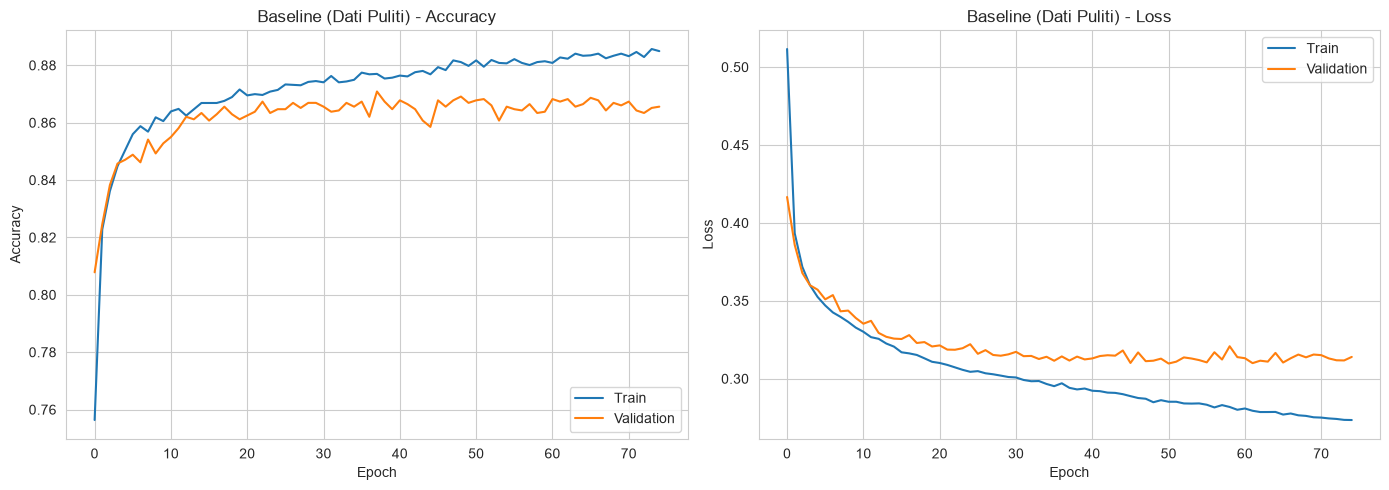

Test loss: 0.3239
Test accuracy: 0.8757


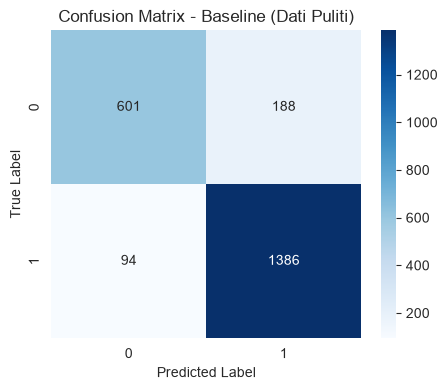

Accuratezza Finale: 0.8757

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.86      0.76      0.81       789
           1       0.88      0.94      0.91      1480

    accuracy                           0.88      2269
   macro avg       0.87      0.85      0.86      2269
weighted avg       0.88      0.88      0.87      2269



 RISULTATI ESPERIMENTO: Rumore 10%


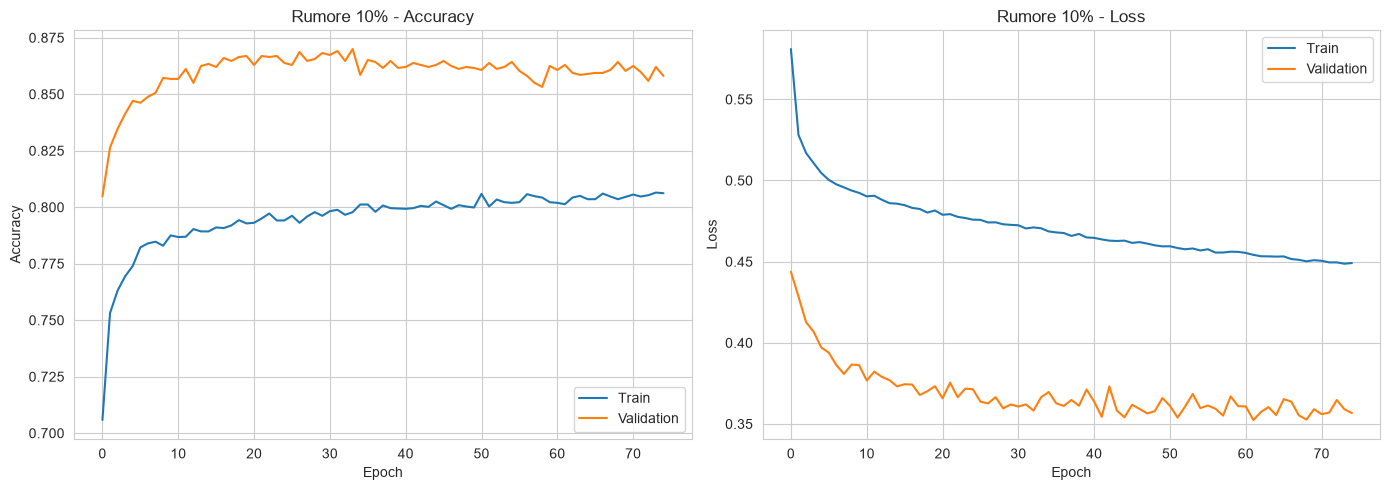

Test loss: 0.3533
Test accuracy: 0.8691


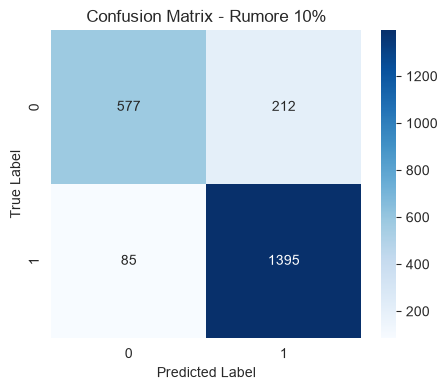

Accuratezza Finale: 0.8691

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.87      0.73      0.80       789
           1       0.87      0.94      0.90      1480

    accuracy                           0.87      2269
   macro avg       0.87      0.84      0.85      2269
weighted avg       0.87      0.87      0.87      2269



 RISULTATI ESPERIMENTO: Rumore 30%


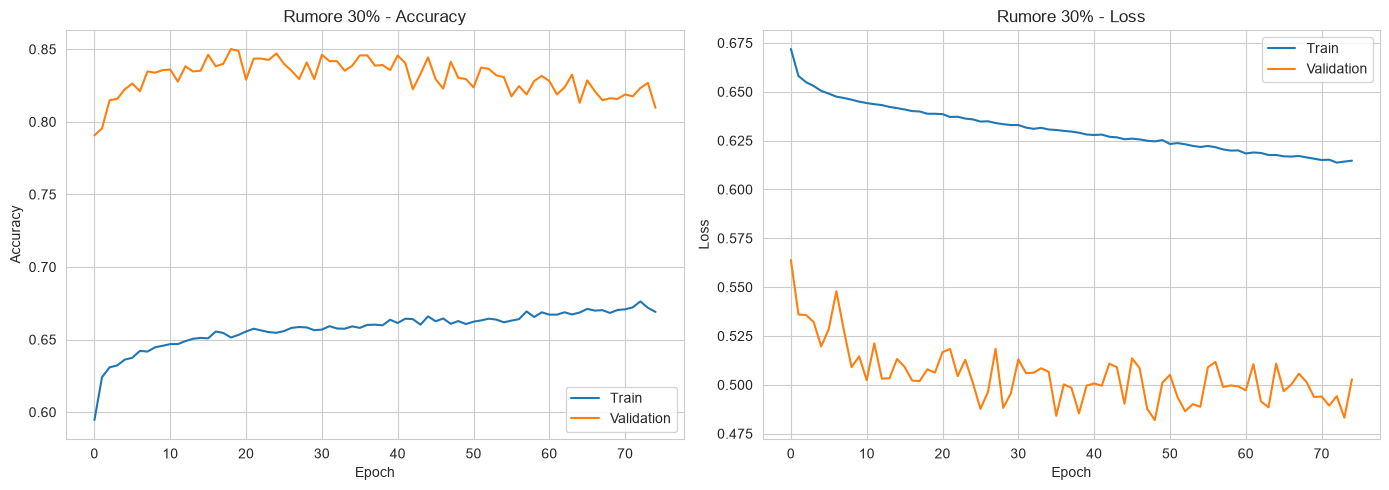

Test loss: 0.4979
Test accuracy: 0.8246


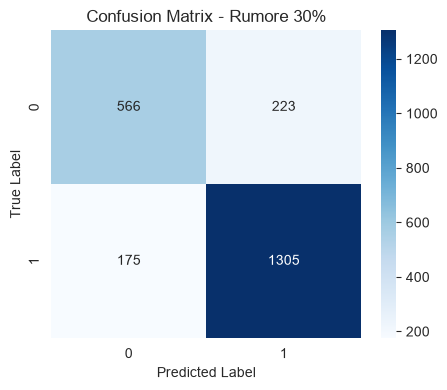

Accuratezza Finale: 0.8246

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.76      0.72      0.74       789
           1       0.85      0.88      0.87      1480

    accuracy                           0.82      2269
   macro avg       0.81      0.80      0.80      2269
weighted avg       0.82      0.82      0.82      2269



 RISULTATI ESPERIMENTO: Rumore 50%


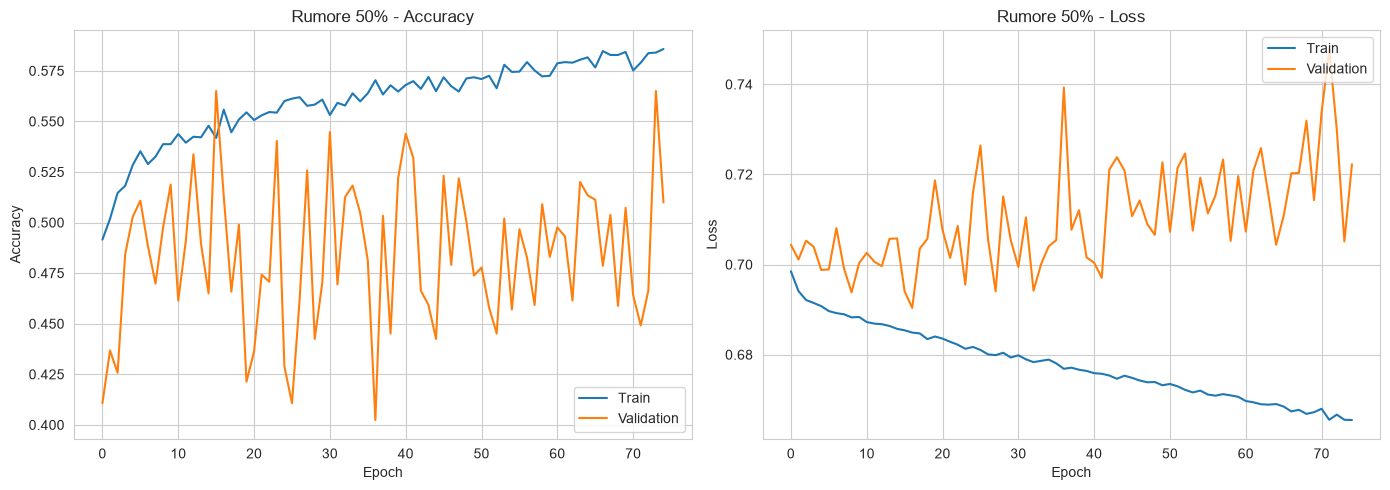

Test loss: 0.7204
Test accuracy: 0.5289


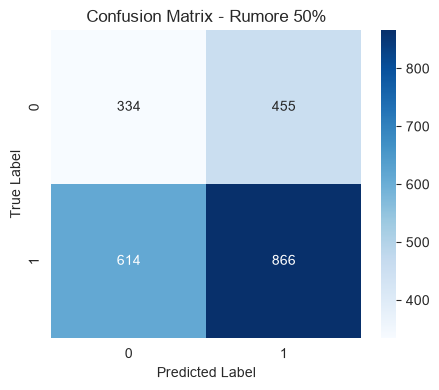

Accuratezza Finale: 0.5289

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.35      0.42      0.38       789
           1       0.66      0.59      0.62      1480

    accuracy                           0.53      2269
   macro avg       0.50      0.50      0.50      2269
weighted avg       0.55      0.53      0.54      2269




In [209]:
# 1. Valutazione Modello sui dati puliti
evaluate_network(model_clean, history_clean, X_test_scaled, y_test, model_name="Baseline (Dati Puliti)")

# 2. Valutazione Modello con rumore al 10%
evaluate_network(model_noise_10_ln, history_noise_10_ln, X_test_scaled, y_test, model_name="Rumore 10%")

# 3. Valutazione Modello con rumore al 30%
evaluate_network(model_noise_30_ln, history_noise_30_ln, X_test_scaled, y_test, model_name="Rumore 30%")

# 4. Valutazione Modello con rumore al 50%
evaluate_network(model_noise_50_ln, history_noise_50_ln, X_test_scaled, y_test, model_name="Rumore 50%")

In [210]:
# 1. Esperimento: Dati Puliti (Baseline)
model_clean, history_clean = train_base_network(X_train_scaled, y_train, X_val_scaled, y_val)

# 2. Esperimento: Dati con 10% di rumore
model_noise_10, history_noise_10 = train_base_network(X_train_fn_10, y_train_ln_10, X_val_scaled, y_val)

# 3. Esperimento: Dati con 30% di rumore
model_noise_30, history_noise_30 = train_base_network(X_train_fn_30, y_train_ln_30, X_val_scaled, y_val)

# 4. Esperimento: Dati con 50% di rumore
model_noise_50, history_noise_50 = train_base_network(X_train_fn_50, y_train_ln_50, X_val_scaled, y_val)

-> Creazione e addestramento della rete in corso... (Epochs: 75)
Epoch 1/75


/Users/matiasbonoli/Downloads/architettura/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 900us/step - accuracy: 0.7517 - loss: 0.5123 - val_accuracy: 0.8052 - val_loss: 0.4219
Epoch 2/75
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 487us/step - accuracy: 0.8207 - loss: 0.4000 - val_accuracy: 0.8272 - val_loss: 0.3915
Epoch 3/75
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 847us/step - accuracy: 0.8345 - loss: 0.3768 - val_accuracy: 0.8427 - val_loss: 0.3703
Epoch 4/75
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 531us/step - accuracy: 0.8470 - loss: 0.3590 - val_accuracy: 0.8471 - val_loss: 0.3568
Epoch 5/75
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 493us/step - accuracy: 0.8554 - loss: 0.3463 - val_accuracy: 0.8506 - val_loss: 0.3519
Epoch 6/75
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 494us/step - accuracy: 0.8626 - loss: 0.3391 - val_accuracy: 0.8537 - val_loss: 0.3454
Epoch 7/75
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 484us/step - accuracy: 0.8620 - loss: 0.3350 - val_accuracy: 0.8572 - val_loss: 0.3373
Epoch 8/75
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 483us/step - accuracy: 0.8645 - loss: 0.3301 - val_accurac


 RISULTATI ESPERIMENTO: Baseline (Dati Puliti)


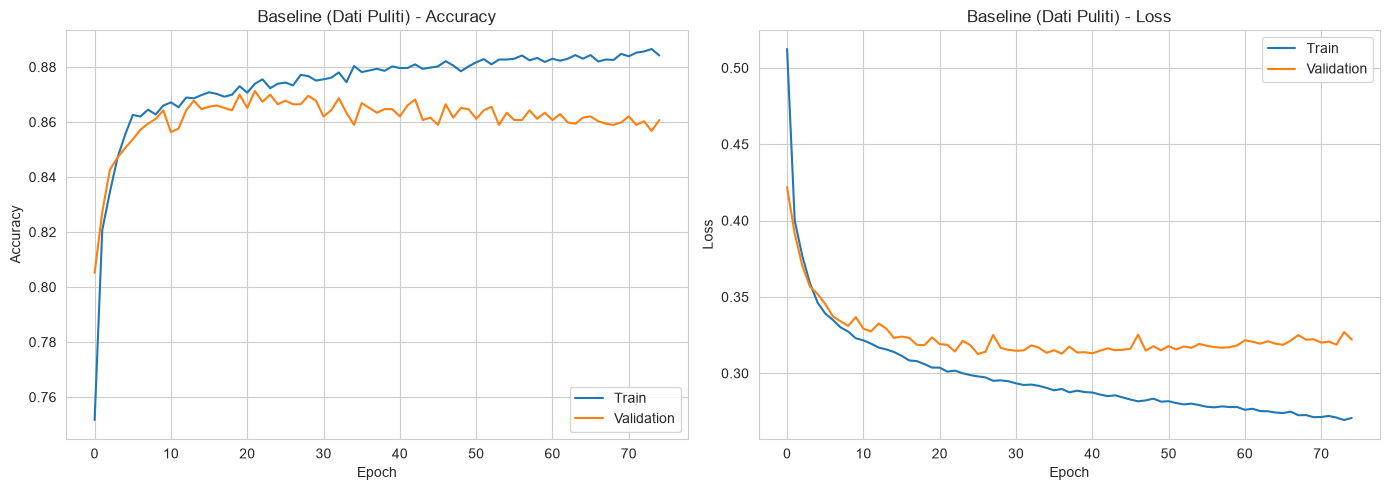

Test loss: 0.3279
Test accuracy: 0.8700


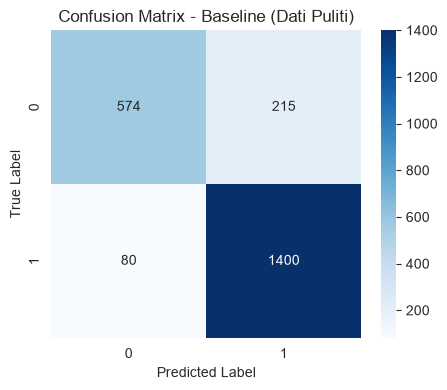

Accuratezza Finale: 0.8700

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.88      0.73      0.80       789
           1       0.87      0.95      0.90      1480

    accuracy                           0.87      2269
   macro avg       0.87      0.84      0.85      2269
weighted avg       0.87      0.87      0.87      2269



 RISULTATI ESPERIMENTO: Rumore 10%


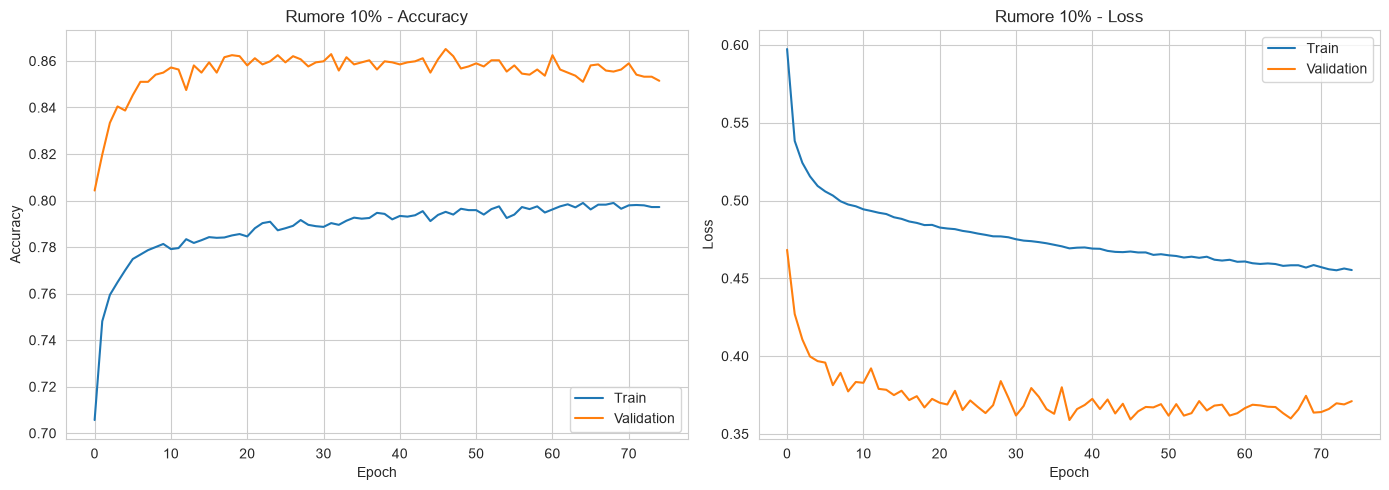

Test loss: 0.3579
Test accuracy: 0.8651


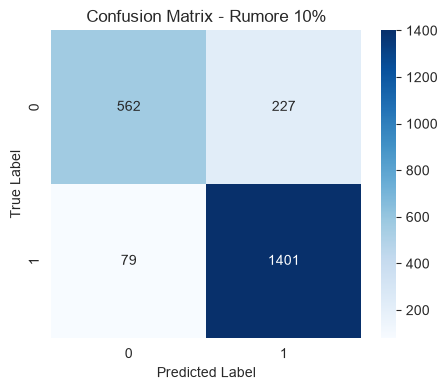

Accuratezza Finale: 0.8651

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.88      0.71      0.79       789
           1       0.86      0.95      0.90      1480

    accuracy                           0.87      2269
   macro avg       0.87      0.83      0.84      2269
weighted avg       0.87      0.87      0.86      2269



 RISULTATI ESPERIMENTO: Rumore 30%


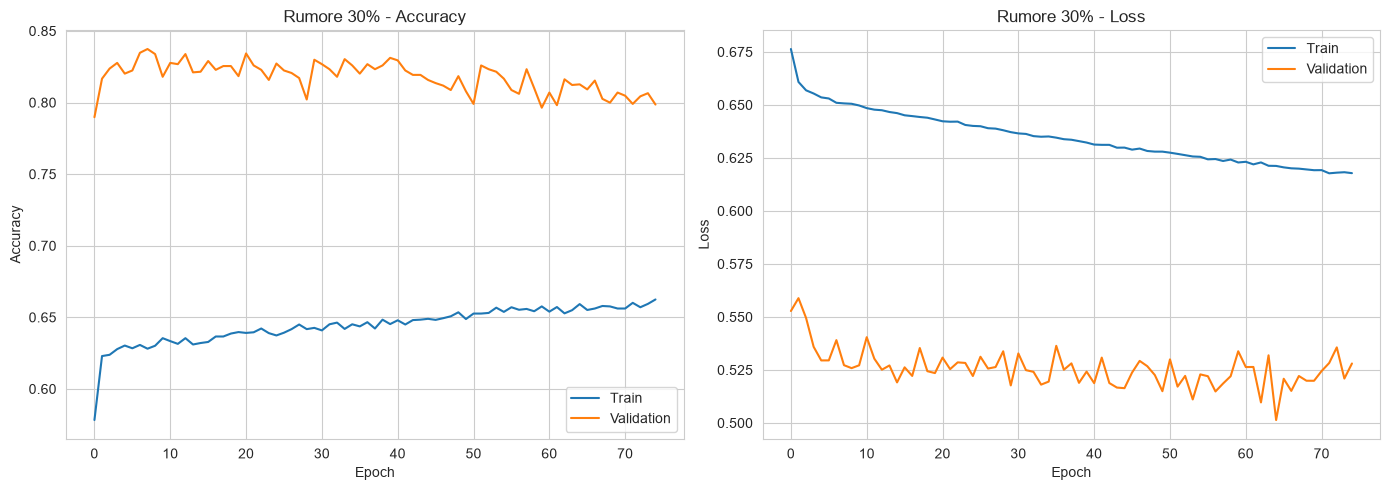

Test loss: 0.5226
Test accuracy: 0.8140


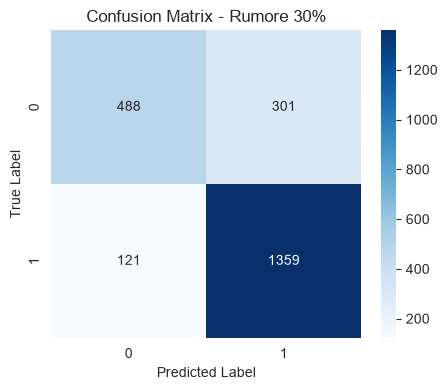

Accuratezza Finale: 0.8140

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.80      0.62      0.70       789
           1       0.82      0.92      0.87      1480

    accuracy                           0.81      2269
   macro avg       0.81      0.77      0.78      2269
weighted avg       0.81      0.81      0.81      2269



 RISULTATI ESPERIMENTO: Rumore 50%


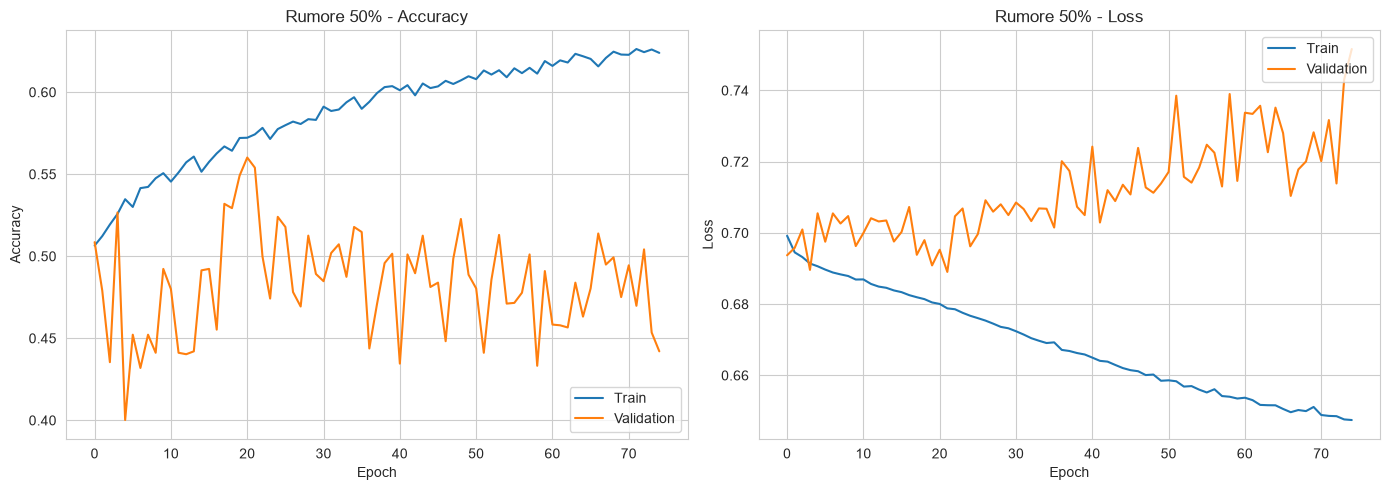

Test loss: 0.7375
Test accuracy: 0.4619


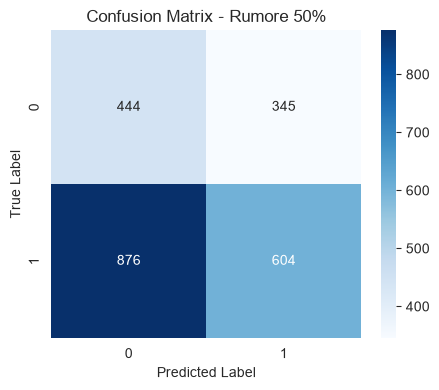

Accuratezza Finale: 0.4619

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.34      0.56      0.42       789
           1       0.64      0.41      0.50      1480

    accuracy                           0.46      2269
   macro avg       0.49      0.49      0.46      2269
weighted avg       0.53      0.46      0.47      2269




In [211]:
# 1. Valutazione Modello sui dati puliti
evaluate_network(model_clean, history_clean, X_test_scaled, y_test, model_name="Baseline (Dati Puliti)")

# 2. Valutazione Modello con rumore al 10%
evaluate_network(model_noise_10, history_noise_10, X_test_scaled, y_test, model_name="Rumore 10%")

# 3. Valutazione Modello con rumore al 30%
evaluate_network(model_noise_30, history_noise_30, X_test_scaled, y_test, model_name="Rumore 30%")

# 4. Valutazione Modello con rumore al 50%
evaluate_network(model_noise_50, history_noise_50, X_test_scaled, y_test, model_name="Rumore 50%")

## Confronto performance

In [173]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

def plot_roc_comparison(models_dict, X_test_input, y_test_input):
    """
    Calcola e traccia le curve ROC per molteplici modelli neurali contemporaneamente.
    
    Parametri:
    - models_dict: Un dizionario Python formato da {'Nome Modello': variabile_modello}
    - X_test_input: I dati di test scalati
    - y_test_input: Le etichette di test vere
    """
    plt.figure(figsize=(10, 7))
    
    # Palette di colori per differenziare le linee
    colors = ['blue', 'green', 'orange', 'purple', 'brown']
    
    # Iteriamo su tutti i modelli che gli passi
    for i, (name, model) in enumerate(models_dict.items()):
        
        # Le reti neurali usano predict() per ottenere le probabilità. 
        # Il .ravel() appiattisce l'array ad una sola dimensione.
        y_score = model.predict(X_test_input, verbose=0).ravel()
        
        # Calcolo FPR, TPR e AUC
        fpr, tpr, _ = roc_curve(y_test_input, y_score)
        auc = roc_auc_score(y_test_input, y_score)
        
        # Scegliamo il colore e tracciamo
        color = colors[i % len(colors)]
        plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.4f})')

    # Linea diagonale di riferimento (classificatore puramente casuale)
    plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=1, alpha=0.5)

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificità)')
    plt.ylabel('True Positive Rate (Sensibilità)')
    plt.title('Confronto Curva ROC: Impatto del Rumore')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

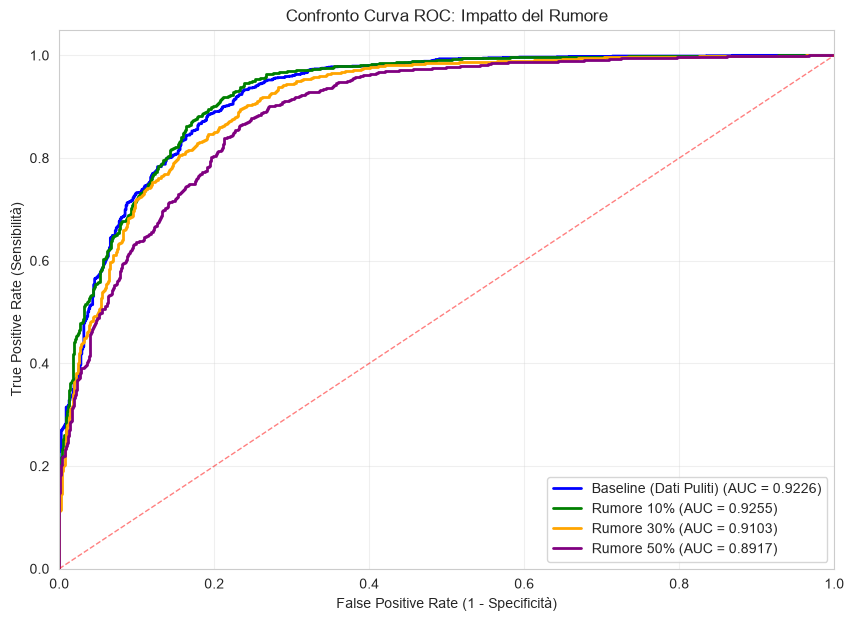

In [ ]:
# Mettiamo i nostri 4 modelli in un dizionario
reti_da_confrontare_fn= {
    'Baseline (Dati Puliti)': model_clean,
    'Rumore 10%': model_noise_10_fn,
    'Rumore 30%': model_noise_30_fn,
    'Rumore 50%': model_noise_50_fn
}

# Generiamo il grafico!
plot_roc_comparison(reti_da_confrontare_fn, X_test_scaled, y_test)

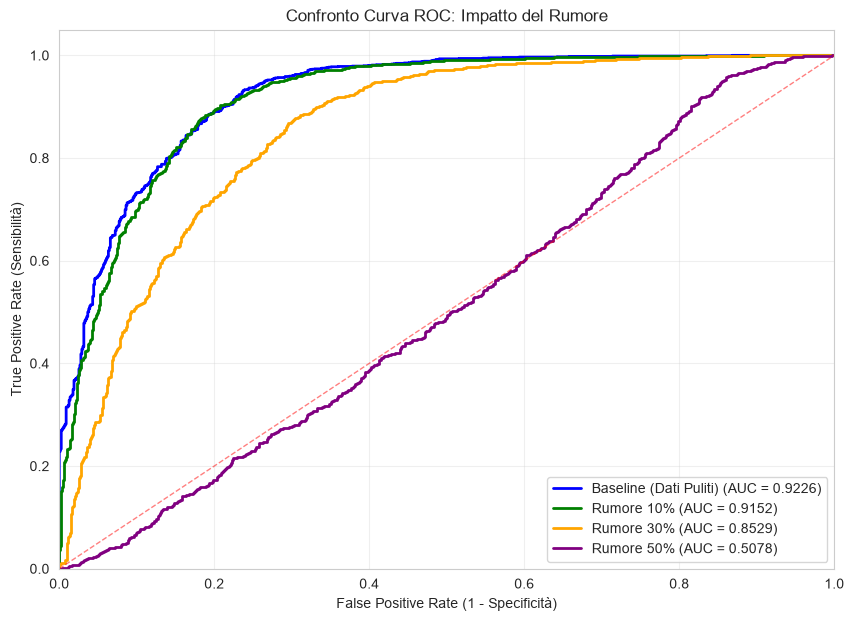

In [197]:
# Mettiamo i nostri 4 modelli in un dizionario
reti_da_confrontare_ln = {
    'Baseline (Dati Puliti)': model_clean,
    'Rumore 10%': model_noise_10_ln,
    'Rumore 30%': model_noise_30_ln,
    'Rumore 50%': model_noise_50_ln
}

# Generiamo il grafico!
plot_roc_comparison(reti_da_confrontare_ln, X_test_scaled, y_test)

--- ANALISI COMPARATIVA ---
Punto di intersezione rilevato a FPR ≈ 0.005
Punto di intersezione rilevato a FPR ≈ 0.082
Punto di intersezione rilevato a FPR ≈ 0.269
Punto di intersezione rilevato a FPR ≈ 0.697
Punto di intersezione rilevato a FPR ≈ 0.714
Punto di intersezione rilevato a FPR ≈ 0.740
Punto di intersezione rilevato a FPR ≈ 0.743
Punto di intersezione rilevato a FPR ≈ 0.746
Punto di intersezione rilevato a FPR ≈ 0.748
Punto di intersezione rilevato a FPR ≈ 0.951


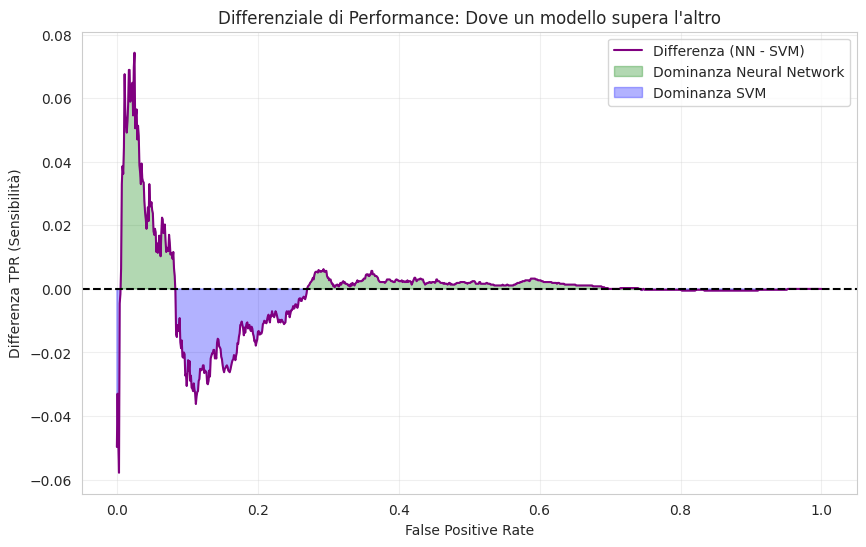

In [ ]:
# Creiamo un range comune di FPR (False Positive Rate) per il confronto
fpr_grid = np.linspace(0, 1, 1000)

# Interpoliamo i TPR (True Positive Rate) di entrambi i modelli sulla stessa griglia
tpr_svm_grid = np.interp(fpr_grid, fpr_svm, tpr_svm)
tpr_nn_grid = np.interp(fpr_grid, fpr_nn, tpr_nn)

# Calcoliamo la differenza (NN - SVM)
# Se > 0, il Decision Tree è sopra (migliore)
# Se < 0, la SVM è sopra (migliore)
diff = tpr_nn_grid - tpr_svm_grid

# Troviamo i punti di intersezione (dove il segno della differenza cambia)
intersections = np.where(np.diff(np.sign(diff)))[0]

print("--- ANALISI COMPARATIVA ---")
for idx in intersections:
    fpr_val = fpr_grid[idx]
    print(f"Punto di intersezione rilevato a FPR ≈ {fpr_val:.3f}")

# Visualizzazione delle aree di dominanza
plt.figure(figsize=(10, 6))
plt.plot(fpr_grid, diff, label='Differenza (NN - SVM)', color='purple')
plt.axhline(0, color='black', linestyle='--')
plt.fill_between(fpr_grid, 0, diff, where=(diff > 0), color='green', alpha=0.3, label='Dominanza Neural Network')
plt.fill_between(fpr_grid, 0, diff, where=(diff < 0), color='blue', alpha=0.3, label='Dominanza SVM')
plt.xlabel('False Positive Rate')
plt.ylabel('Differenza TPR (Sensibilità)')
plt.title('Differenziale di Performance: Dove un modello supera l\'altro')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()